In [76]:
from ggner_3d.cm import CLR_CONNS
import cooler
import cooltools
import pandas as pd
import os
from ggner_3d import plotting
from statannotations.Annotator import Annotator
import ptitprince as pt
import matplotlib.pyplot as plt


resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution=resolution)

In [77]:
insulation_dfs_path = '/home/carlos/Clone/ggner-3d/data/insulation'
insulation_dfs = [
    pd.read_csv(os.path.join(insulation_dfs_path, f"insulation_{f}_{resolution}bp.csv")) for f in clr_.keys()
]

In [78]:
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd


def _expand_indices(idxs: Sequence[int], accepted_range: int) -> Tuple[List[int], List[int]]:
    expanded: List[int] = []
    expanded_original: List[int] = []
    for idx in idxs:
        rng = list(range(int(idx) - accepted_range, int(idx) + accepted_range + 1))
        expanded.extend(rng)
        expanded_original.extend([int(idx)] * len(rng))
    return expanded, expanded_original


def preserved_boundaries_only(
    comparisons: Sequence[Tuple[int, int]],
    insulation_table_: Sequence[pd.DataFrame],
    sample_names_str: Sequence[str],
    window: Any,
    accepted_range: int = 1,
    comparisons_str: Optional[Sequence[str]] = None,
    verbose: bool = True,
) -> Tuple[List[Dict[str, List[Tuple[int, int]]]], List[pd.DataFrame]]:
    """
    Only computes PRESERVED boundaries and splits them into Increase vs Decrease.

    Output DF per comparison includes:
      - chrom/start/end for BOTH samples (at idx1 / idx2)
      - boundary_strength_{window} for BOTH samples
    """
    preserved_results: List[Dict[str, List[Tuple[int, int]]]] = []
    preserved_dfs: List[pd.DataFrame] = []

    bs_col = f"boundary_strength_{window}"
    b_col = f"is_boundary_{window}"

    required_cols = {"chrom", "start", "end", bs_col, b_col}

    for comp_idx, (i, j) in enumerate(comparisons):
        # Make sure iloc positions align with integer indices
        ins_df1 = insulation_table_[i].copy().reset_index(drop=True)
        ins_df2 = insulation_table_[j].copy().reset_index(drop=True)

        missing1 = required_cols - set(ins_df1.columns)
        missing2 = required_cols - set(ins_df2.columns)
        if missing1:
            raise ValueError(f"Sample1 df missing columns: {sorted(missing1)}")
        if missing2:
            raise ValueError(f"Sample2 df missing columns: {sorted(missing2)}")

        b1 = ins_df1.loc[ins_df1[b_col] == True].index.to_numpy().astype(int)
        b2 = ins_df2.loc[ins_df2[b_col] == True].index.to_numpy().astype(int)

        b1_exp, b1_exp_orig = _expand_indices(b1, accepted_range)

        preserved_pairs: List[Tuple[int, int]] = []
        for idx_2 in b2:
            idx_2 = int(idx_2)
            if idx_2 in b1_exp:
                k = b1_exp.index(idx_2)  # preserves your original "first match" behavior
                idx_1 = int(b1_exp_orig[k])
                preserved_pairs.append((idx_1, idx_2))

        res: Dict[str, List[Tuple[int, int]]] = {"Increase": [], "Decrease": []}
        rows: List[Dict[str, Any]] = []

        for idx_1, idx_2 in preserved_pairs:
            r1 = ins_df1.iloc[idx_1]
            r2 = ins_df2.iloc[idx_2]

            bs1 = r1[bs_col]
            bs2 = r2[bs_col]

            direction = "Increase" if bs2 > bs1 else "Decrease"
            res[direction].append((idx_1, idx_2))

            rows.append(
                dict(
                    sample1=sample_names_str[i],
                    sample2=sample_names_str[j],
                    dir=direction,
                    idx1=int(idx_1),
                    idx2=int(idx_2),
                    chrom1=r1["chrom"],
                    start1=int(r1["start"]),
                    end1=int(r1["end"]),
                    chrom2=r2["chrom"],
                    start2=int(r2["start"]),
                    end2=int(r2["end"]),
                    bs1=float(bs1) if pd.notna(bs1) else np.nan,
                    bs2=float(bs2) if pd.notna(bs2) else np.nan,
                )
            )

        preserved_results.append(res)

        df_now = pd.DataFrame(
            rows,
            columns=[
                "sample1", "sample2", "dir", "idx1", "idx2",
                "chrom1", "start1", "end1",
                "chrom2", "start2", "end2",
                "bs1", "bs2",
            ],
        )
        preserved_dfs.append(df_now)

    if verbose:
        for comp_idx, (i, j) in enumerate(comparisons):
            tag = (
                comparisons_str[comp_idx]
                if comparisons_str is not None
                else f"{sample_names_str[i]} vs {sample_names_str[j]}"
            )
            inc_n = len(preserved_results[comp_idx]["Increase"])
            dec_n = len(preserved_results[comp_idx]["Decrease"])
            print(f"{tag}: Preserved / Increase ::: {inc_n}")
            print(f"{tag}: Preserved / Decrease ::: {dec_n}")

    return preserved_results, preserved_dfs


In [79]:
base_sample = 'WTnoUV'
sample_names_str = list(clr_.keys())

base_sample_idx = sample_names_str.index(base_sample)
comparisons = [(base_sample_idx, i) for i in range(len(sample_names_str)) if i != base_sample_idx]
comparisons_str = [f"{base_sample}_{sample_names_str[i]}" for i in range(len(sample_names_str)) if i != base_sample_idx]
base_sample_idx = sample_names_str.index(base_sample)

results, comps_dfs_ = preserved_boundaries_only(
    comparisons=comparisons,
    insulation_table_=insulation_dfs,
    sample_names_str=sample_names_str,
    window=window,
    accepted_range=2,
    comparisons_str=comparisons_str,
    verbose=True,
)

WTnoUV_WT1h: Preserved / Increase ::: 1879
WTnoUV_WT1h: Preserved / Decrease ::: 871
WTnoUV_WT3h: Preserved / Increase ::: 1630
WTnoUV_WT3h: Preserved / Decrease ::: 1042
WTnoUV_WT6h: Preserved / Increase ::: 1233
WTnoUV_WT6h: Preserved / Decrease ::: 1322
WTnoUV_XPAnoUV: Preserved / Increase ::: 1147
WTnoUV_XPAnoUV: Preserved / Decrease ::: 1473
WTnoUV_XPA1h: Preserved / Increase ::: 1334
WTnoUV_XPA1h: Preserved / Decrease ::: 1313
WTnoUV_XPA3h: Preserved / Increase ::: 1264
WTnoUV_XPA3h: Preserved / Decrease ::: 1269
WTnoUV_XPA6h: Preserved / Increase ::: 415
WTnoUV_XPA6h: Preserved / Decrease ::: 1846
WTnoUV_XPCnoUV: Preserved / Increase ::: 2451
WTnoUV_XPCnoUV: Preserved / Decrease ::: 369
WTnoUV_XPC3h: Preserved / Increase ::: 2092
WTnoUV_XPC3h: Preserved / Decrease ::: 493


In [80]:
# import man whitney
from scipy.stats import mannwhitneyu

for i, df in enumerate(comps_dfs_):
    print(f"Comparison: {comparisons_str[i]}, n={len(df)}")
    stat, p = mannwhitneyu(df.bs1, df.bs2, alternative="two-sided")
    print(f"Statistic: {stat}, p-value: {p}")

Comparison: WTnoUV_WT1h, n=2750
Statistic: 3639446.0, p-value: 0.016023725496888967
Comparison: WTnoUV_WT3h, n=2672
Statistic: 3462228.0, p-value: 0.056466842295632924
Comparison: WTnoUV_WT6h, n=2555
Statistic: 3280861.0, p-value: 0.7493338541360276
Comparison: WTnoUV_XPAnoUV, n=2620
Statistic: 3498066.0, p-value: 0.22900352899952547
Comparison: WTnoUV_XPA1h, n=2647
Statistic: 3517575.0, p-value: 0.7974551759713563
Comparison: WTnoUV_XPA3h, n=2533
Statistic: 3215855.0, p-value: 0.8807265262495385
Comparison: WTnoUV_XPA6h, n=2261
Statistic: 3021458.0, p-value: 2.9072098446610336e-26
Comparison: WTnoUV_XPCnoUV, n=2820
Statistic: 3521989.0, p-value: 1.0955941214366855e-13
Comparison: WTnoUV_XPC3h, n=2585
Statistic: 2908257.0, p-value: 7.234090439650417e-16


In [82]:
order = [
    'WTnoUV',
    'WT1h',
    'WT3h',
    'WT6h',
    'XPCnoUV',
    'XPC3h',
    'XPAnoUV',
    'XPA1h',
    'XPA3h',
    'XPA6h'
]

/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1143: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.0}` instead.

  sns.pointplot(


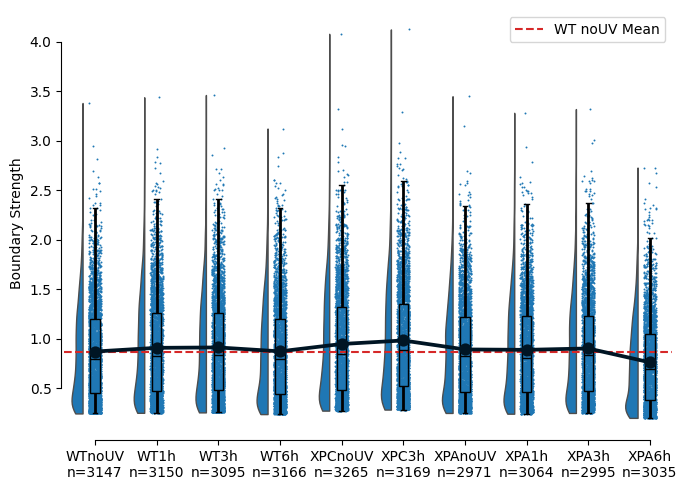

In [88]:
plot_boundary_df = {
    'bs': [],
    'sample': [],
}

for i, df in enumerate(insulation_dfs):
    current_boundary_df = df.copy()
    current_boundary_df = current_boundary_df[current_boundary_df[f"is_boundary_{window}"] == True].reset_index(drop=True)

    plot_boundary_df['bs'].extend(current_boundary_df[f"boundary_strength_{window}"].tolist())
    plot_boundary_df['sample'].extend([sample_names_str[i]] * len(current_boundary_df))

plot_boundary_df = pd.DataFrame(plot_boundary_df)
ort = 'v'
# pal = plotting.COLORS
dx = 'sample'
dy = 'bs'
sigma = 0.2


# -----------------------
# raincloud plot
# -----------------------
fig, ax = plt.subplots(figsize=(7, 5))

# NOTE: Don't set hue="sample" when x="sample" (redundant and can confuse annotation pairing).
ax = pt.RainCloud(
    x=dx,
    y=dy,
    data=plot_boundary_df,
    order=order,
    bw=sigma,
    width_viol=0.4,
    ax=ax,
    orient=ort,
    move=0.0,
    pointplot=True,
    point_size=1.4,
    linecolor="#001524",
    box_showfliers=False,
)

ax.set_ylabel('Boundary Strength')
# add n boundaries to x tick labels
xticks = []
for sample in order:
    n_boundaries = plot_boundary_df.loc[plot_boundary_df['sample'] == sample, 'bs'].shape[0]
    xticks.append(f'{sample}\nn={n_boundaries}')
ax.set_xticklabels(xticks)
ax.set_xlabel('')

# WT mean line

wt_mean = plot_boundary_df.loc[plot_boundary_df['sample'] == 'WTnoUV', 'bs'].mean()
ax.axhline(wt_mean, color='#d62828', linestyle='--', label='WT noUV Mean')

pairs = [(order[0], g) for g in order[1:]]  # WT noUV vs each other sample

annot = Annotator(
    ax,
    pairs,
    data=plot_boundary_df,
    x=dx,
    y=dy,
    order=order,
)

annot.configure(
    test="Mann-Whitney",              # alternatives: "t-test_ind", "Wilcoxon", ...
    text_format="star",               # alternatives: "simple" (shows p=...)
    loc="inside",                    # keeps brackets above the plot
    verbose=0
)

# annot.apply_and_annotate()

ax.legend()
plotting.despine(ax)
plt.tight_layout()